In [1]:
#Practice
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [7]:
data=pd.read_csv('/content/Salary_Data.csv')

In [8]:
data.head()

,YearsExperience,Salary
0,4.6,74300
1,10.0,122900
2,8.0,106600
3,6.7,79700
4,2.6,53200


In [9]:
data.shape

(100, 2)

In [10]:
data.isnull().sum()

,0
YearsExperience,0
Salary,0


In [11]:
x=data.iloc[:,:1].values
y=data.iloc[:, 1:2].values

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state =42)

In [13]:
model=LinearRegression()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)

In [14]:
print(y_pred)
print(y_test)

[[ 46972.85669823]
 [118722.8811232 ]
 [108604.28793506]
 [ 98485.69474692]
 [ 63530.55464245]
 [ 79168.38047866]
 [ 66290.17096649]
 [115963.26479916]
 [ 43293.36826618]
 [ 73649.14783059]
 [ 79168.38047866]
 [ 93886.33420686]
 [112283.77636711]
 [123322.24166326]
 [ 51572.21723829]
 [ 55251.70567034]
 [107684.41582705]
 [ 47892.72880624]
 [113203.64847512]
 [ 56171.57777835]]
[[ 50700]
 [116700]
 [101100]
 [ 93000]
 [ 68800]
 [ 81500]
 [ 66100]
 [130500]
 [ 48800]
 [ 74300]
 [ 76700]
 [107800]
 [115700]
 [124500]
 [ 56700]
 [ 53200]
 [104100]
 [ 48700]
 [110800]
 [ 56900]]


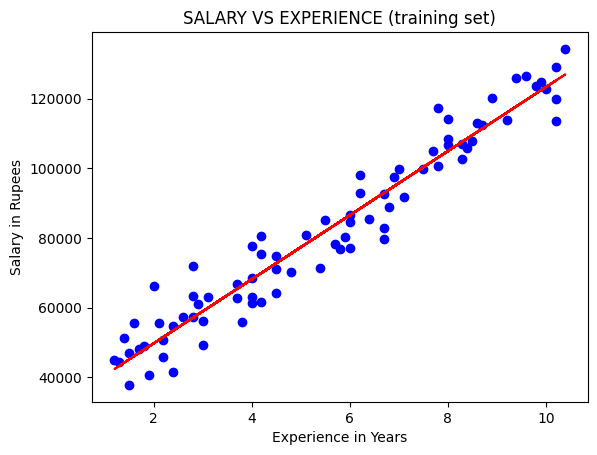

In [15]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, model.predict(x_train), color='red')
plt.title('SALARY VS EXPERIENCE (training set)')
plt.xlabel('Experience in Years')
plt.ylabel('Salary in Rupees')
plt.show()

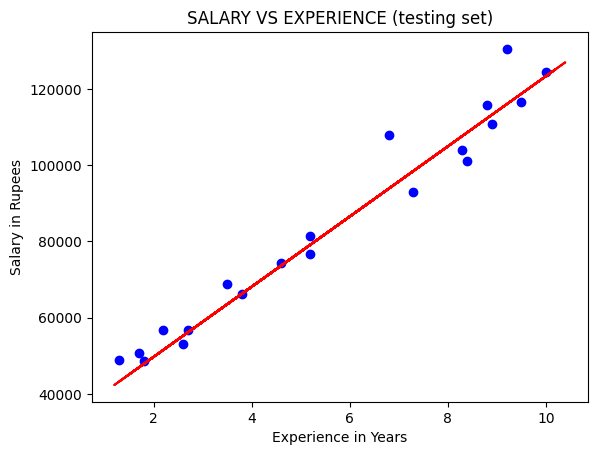

In [16]:
plt.scatter(x_test, y_test, color='blue')
plt.plot(x_train, model.predict(x_train), color='red')
plt.title('SALARY VS EXPERIENCE (testing set)')
plt.xlabel('Experience in Years')
plt.ylabel('Salary in Rupees')
plt.show()

In [18]:
#Exercise
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [19]:
url = "https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [20]:
print("Shape of dataset:")
print(df.shape)
print("\nFirst 5 rows:")
display(df.head())

Shape of dataset:
(31694, 18)

First 5 rows:


,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [21]:
print("Column names:")
print(df.columns)
print("\nDataset information:")
df.info()

Column names:
Index(['TRIP_START_TIMESTAMP', 'TRIP_END_TIMESTAMP', 'TRIP_START_HOUR',
       'TRIP_SECONDS', 'TRIP_MILES', 'TRIP_SPEED', 'PICKUP_CENSUS_TRACT',
       'DROPOFF_CENSUS_TRACT', 'PICKUP_COMMUNITY_AREA',
       'DROPOFF_COMMUNITY_AREA', 'FARE', 'TIPS', 'TIP_RATE', 'TOLLS', 'EXTRAS',
       'TRIP_TOTAL', 'PAYMENT_TYPE', 'COMPANY'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TRIP_START_TIMESTAMP    31694 non-null  object 
 1   TRIP_END_TIMESTAMP      31694 non-null  object 
 2   TRIP_START_HOUR         31694 non-null  float64
 3   TRIP_SECONDS            31694 non-null  int64  
 4   TRIP_MILES              31694 non-null  float64
 5   TRIP_SPEED              31694 non-null  float64
 6   PICKUP_CENSUS_TRACT     13259 non-null  float64
 7   DROPOFF_CENSUS_TRACT

In [22]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
TRIP_START_TIMESTAMP          0
TRIP_END_TIMESTAMP            0
TRIP_START_HOUR               0
TRIP_SECONDS                  0
TRIP_MILES                    0
TRIP_SPEED                    0
PICKUP_CENSUS_TRACT       18435
DROPOFF_CENSUS_TRACT      17671
PICKUP_COMMUNITY_AREA      3217
DROPOFF_COMMUNITY_AREA     3495
FARE                          0
TIPS                          0
TIP_RATE                      0
TOLLS                         0
EXTRAS                        0
TRIP_TOTAL                    0
PAYMENT_TYPE                  0
COMPANY                       0
dtype: int64


In [23]:
df.describe()

,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL
count,31694.000000,31694.000000,31694.000000,31694.000000,1.325900e+04,1.402300e+04,28477.000000,28199.000000,31694.000000,31694.000000,31694.000000,31694.000000,31694.000000,31694.000000
mean,14.185635,1319.796397,8.289463,20.256544,1.703153e+10,1.703140e+10,35.562138,25.550410,23.905210,3.246130,12.965785,0.002744,2.410468,29.755053
std,5.159454,928.932873,7.265672,11.110390,3.827747e+05,3.408106e+05,26.421367,20.349707,16.970022,4.284567,15.517765,0.164343,5.805087,23.145537
min,0.000000,60.000000,0.500000,4.000000,1.703102e+10,1.703101e+10,1.000000,1.000000,3.250000,0.000000,0.000000,0.000000,0.000000,3.250000
25%,10.500000,548.000000,1.720000,11.000000,1.703108e+10,1.703108e+10,8.000000,8.000000,9.000000,0.000000,0.000000,0.000000,0.000000,10.750000
50%,14.750000,1081.000000,5.920000,17.600000,1.703132e+10,1.703132e+10,32.000000,28.000000,18.750000,2.000000,12.200000,0.000000,0.000000,21.700000
75%,18.000000,1888.000000,14.500000,27.500000,1.703198e+10,1.703184e+10,59.000000,32.000000,38.750000,5.000000,20.800000,0.000000,4.000000,48.265000
max,23.750000,7140.000000,68.120000,64.800000,1.703198e+10,1.703198e+10,77.000000,77.000000,159.250000,60.000000,648.600000,27.000000,85.000000,248.500000


In [24]:
X = df[["TRIP_MILES", "TRIP_SECONDS"]]
y = df["FARE"]
print("Features:")
display(X.head())
print("\nTarget:")
display(y.head())

Features:


,TRIP_MILES,TRIP_SECONDS
0,2.57,2341
1,1.18,1074
2,1.29,1173
3,3.70,3360
4,1.15,1044



Target:


,FARE
0,31.99
1,9.75
2,10.25
3,23.75
4,10.00


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25355, 2)
Testing data: (6339, 2)


In [26]:
model = LinearRegression()
print("Linear Regression model created.")

Linear Regression model created.


In [27]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [28]:
print("Model coefficients:")
print("TRIP_MILES coefficient:",model.coef_[0])
print("TRIP_SECONDS coefficient:",model.coef_[1])
print("Intercept:",model.intercept_)

Model coefficients:
TRIP_MILES coefficient: 2.0163424402219015
TRIP_SECONDS coefficient: 0.002518164709808542
Intercept: 3.857050051628825


In [29]:
y_pred = model.predict(X_test)
print("Predictions generated successfully!")

Predictions generated successfully!


In [30]:
results = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": y_pred
})
display(results.head(10))

,Actual Fare,Predicted Fare
0,14.84,15.814179
1,4.75,5.454671
2,33.50,33.371033
3,23.00,23.506082
4,9.68,9.730513
5,46.25,44.986090
6,9.75,10.514532
7,11.75,11.213712
8,58.71,45.016725
9,8.00,8.440453


In [31]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.2064482237745378
Mean Squared Error (MSE): 12.99294875045945
Root Mean Squared Error (RMSE): 3.6045733104570714
R² Score: 0.9560758603951844


In [33]:
new_trip = pd.DataFrame({
    "TRIP_MILES": [5],
    "TRIP_SECONDS": [900]
})
predicted_fare = model.predict(new_trip)
print("Predicted Taxi Fare: $", round(predicted_fare[0], 2))

Predicted Taxi Fare: $ 16.21


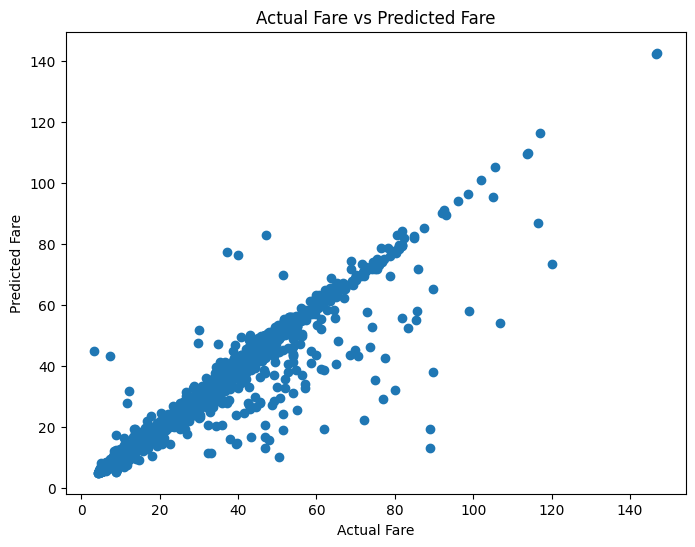

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual Fare vs Predicted Fare")
plt.show()

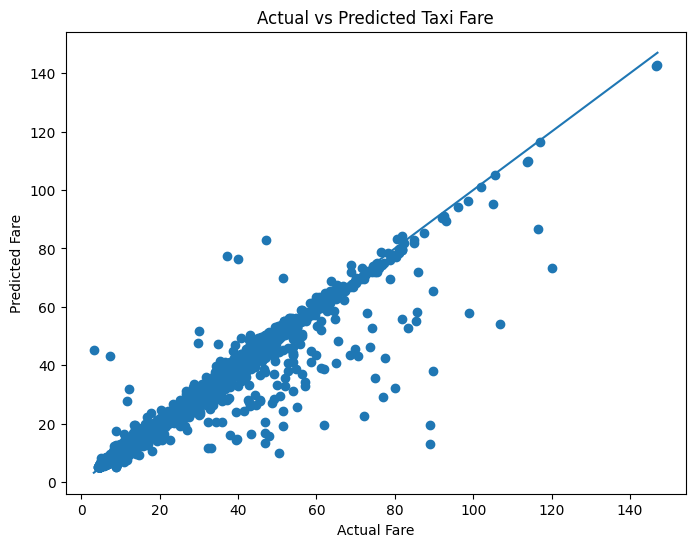

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Taxi Fare")
plt.show()

In [36]:
#Exercise
#2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [37]:
data = {
    "Weight": [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    "Height": [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    "Age": [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    "Gender": [
        "Male", "Male", "Male", "Male", "Male",
        "Female", "Female", "Female", "Female", "Female"
    ]
}
df = pd.DataFrame(data)
display(df)

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


In [38]:
print("Shape of dataset:")
print(df.shape)
print("\nColumn names:")
print(df.columns)
print("\nDataset information:")
df.info()

Shape of dataset:
(10, 4)

Column names:
Index(['Weight', 'Height', 'Age', 'Gender'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  10 non-null     int64  
 1   Height  10 non-null     float64
 2   Age     10 non-null     int64  
 3   Gender  10 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 452.0+ bytes


In [39]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Weight    0
Height    0
Age       0
Gender    0
dtype: int64


In [40]:
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})
display(df)

,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1
5,55,1.55,18,0
6,69,1.50,89,0
7,71,1.78,42,0
8,64,1.67,16,0
9,69,1.64,52,0


In [41]:
X = df[["Height", "Age", "Gender"]]
y = df["Weight"]
print("Independent variables:")
display(X)
print("\nDependent variable:")
display(y)

Independent variables:


,Height,Age,Gender
0,1.80,35,1
1,1.68,39,1
2,1.82,25,1
3,1.70,60,1
4,1.87,27,1
5,1.55,18,0
6,1.50,89,0
7,1.78,42,0
8,1.67,16,0
9,1.64,52,0



Dependent variable:


,Weight
0,79
1,69
2,73
3,95
4,82
5,55
6,69
7,71
8,64
9,69


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:")
print(X_train.shape)
print("\nTesting data:")
print(X_test.shape)

Training data:
(8, 3)

Testing data:
(2, 3)


In [43]:
model = LinearRegression()
print("Linear Regression model created.")

Linear Regression model created.


In [44]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [45]:
print("Intercept:", model.intercept_)
print("\nCoefficients:")
print("Height:", model.coef_[0])
print("Age:", model.coef_[1])
print("Gender:", model.coef_[2])

Intercept: -3.0552172392595196

Coefficients:
Height: 32.83533630032696
Age: 0.3172947417608091
Gender: 14.623118479712073


In [46]:
y_pred = model.predict(X_test)
print("Predicted weights:")
print(y_pred)

Predicted weights:
[56.85651025 79.10576115]


In [47]:
results = pd.DataFrame({
    "Actual Weight": y_test.values,
    "Predicted Weight": y_pred
})
display(results)

,Actual Weight,Predicted Weight
0,64,56.856510
1,69,79.105761


In [48]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

Mean Absolute Error: 8.624625451606978
Mean Squared Error: 76.57792714844265
Root Mean Squared Error: 8.750881506936468
R² Score: -11.252468343750825


In [49]:
new_person = pd.DataFrame({
    "Height": [1.75],
    "Age": [30],
    "Gender": [1]
})
predicted_weight = model.predict(new_person)
print("Predicted body weight:",round(predicted_weight[0], 2),"kg")

Predicted body weight: 78.55 kg
